In [1]:
import pandas as pd
import numpy as np


In [11]:
data = {
    'Age': [22, 25, 30, 28, np.nan, 35, 40, np.nan],
    'Salary': [30000, 32000, 35000, 37000, np.nan, 1000000, 1200000, np.nan],  # outliers 🚨
    'Experience': [1, 2, 3, 2, np.nan, 10, 12, np.nan]
}

df = pd.DataFrame(data)
print("Original Data:\n", df)

Original Data:
     Age     Salary  Experience
0  22.0    30000.0         1.0
1  25.0    32000.0         2.0
2  30.0    35000.0         3.0
3  28.0    37000.0         2.0
4   NaN        NaN         NaN
5  35.0  1000000.0        10.0
6  40.0  1200000.0        12.0
7   NaN        NaN         NaN


In [12]:
df_pandas = df.copy()

In [13]:
df_pandas.isnull().sum()

,0
Age,2
Salary,2
Experience,2


###Through Pandas

In [25]:


# Apply median imputation
df['ageMedian'] = df_pandas['Age'].fillna(df_pandas['Age'].median())
df['medianSalary'] = df_pandas['Salary'].fillna(df_pandas['Salary'].median())
df['medianExperience'] = df_pandas['Experience'].fillna(df_pandas['Experience'].median())



In [32]:
df_combined = df[['ageMedian', 'medianSalary', 'medianExperience']]

In [33]:
df_combined

,ageMedian,medianSalary,medianExperience
0,22.0,30000.0,1.0
1,25.0,32000.0,2.0
2,30.0,35000.0,3.0
3,28.0,37000.0,2.0
4,29.0,36000.0,2.5
5,35.0,1000000.0,10.0
6,40.0,1200000.0,12.0
7,29.0,36000.0,2.5


In [34]:
df_combined.isnull().sum()

,0
ageMedian,0
medianSalary,0
medianExperience,0


<Axes: >

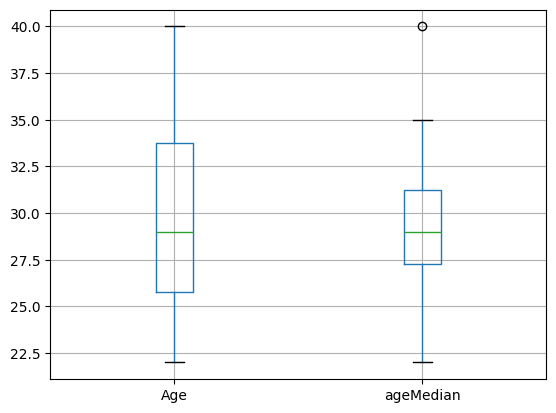

In [27]:
df[['Age', 'ageMedian']].boxplot()

<Axes: >

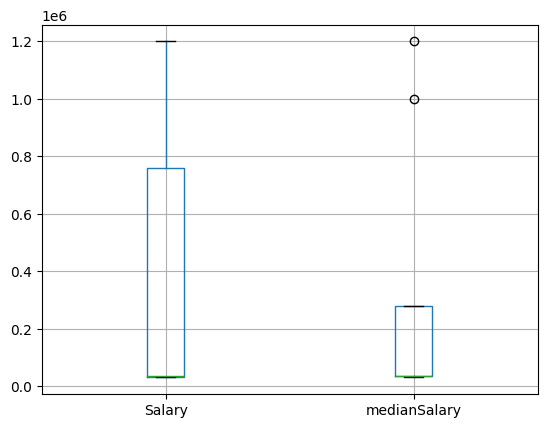

In [28]:
df[['Salary', 'medianSalary']].boxplot()

<Axes: >

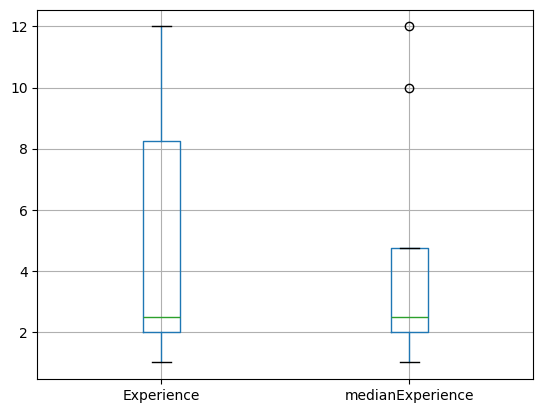

In [30]:
df[['Experience', 'medianExperience']].boxplot()

####SkLearn Apply

In [22]:
from sklearn.impute import SimpleImputer

# Create imputer
median_imputer = SimpleImputer(strategy='median')

# Apply transformation
df_sklearn = pd.DataFrame( median_imputer.fit_transform(df), columns=df.columns)


In [23]:
df_sklearn

,Age,Salary,Experience
0,22.0,30000.0,1.0
1,25.0,32000.0,2.0
2,30.0,35000.0,3.0
3,28.0,37000.0,2.0
4,29.0,36000.0,2.5
5,35.0,1000000.0,10.0
6,40.0,1200000.0,12.0
7,29.0,36000.0,2.5


In [24]:
df_sklearn.isnull().sum()

,0
Age,0
Salary,0
Experience,0
